# Week11 Spatio-Temporal Fusion

本 Notebook 对应第十一周任务：复用 PVOD 多站点光伏数据和第九周图结构，完成 `Input -> GCN -> LSTM -> Output` 的时空融合实验，并加入 15min / 1h 双分支 Add 融合。

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

_cwd = os.getcwd()
_root = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'week11' else _cwd
sys.path.insert(0, os.path.join(_root, 'week11'))

# Clear same-name modules that may have been imported from previous weeks.
for _module_name in ['data', 'models', 'train', 'visualization']:
    if _module_name in sys.modules:
        del sys.modules[_module_name]

from data import prepare_st_data
from models import IndependentLSTM, GCNLSTMRegressor, MultiScaleGCNLSTMRegressor
from train import SingleScaleGraphDataset, MultiScaleGraphDataset, train_model

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Torch version: {torch.__version__}')
print(f'Device: {device}')

Torch version: 2.6.0+cu124
Device: cuda


## 1. 实验参数

15min 分支使用最近 16 个 15min 时间点，即 4 小时历史；1h 分支使用最近 4 个小时点。

In [2]:
FEATURE_COLUMNS = [
    'power',
    'nwp_globalirrad',
    'nwp_directirrad',
    'nwp_temperature',
    'nwp_humidity',
    'nwp_windspeed',
]
SEQ_LEN_15MIN = 16
SEQ_LEN_1H = 4
PRED_HORIZON = 1
DIST_THRESHOLD_KM = 150.0
BATCH_SIZE = 16
EPOCHS = 5
LR = 1e-3
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 2. 构造时空样本

输入张量保留时间维，形状为 `[samples, seq_len, stations, features]`。

In [3]:
prepared = prepare_st_data(
    feature_columns=FEATURE_COLUMNS,
    distance_threshold_km=DIST_THRESHOLD_KM,
    seq_len_15min=SEQ_LEN_15MIN,
    seq_len_1h=SEQ_LEN_1H,
    pred_horizon=PRED_HORIZON,
)

print(f'Stations: {prepared.station_ids}')
print(f'Train 15min X: {prepared.train_x_15min.shape}')
print(f'Train 1h X: {prepared.train_x_1h.shape}')
print(f'Train y: {prepared.train_y.shape}')
print(f'Test 15min X: {prepared.test_x_15min.shape}')
print(f'Test 1h X: {prepared.test_x_1h.shape}')
print(f'Test y: {prepared.test_y.shape}')
print(f'Edge index: {prepared.edge_index.shape}')

Stations: ['station00', 'station01', 'station02', 'station03', 'station04', 'station05', 'station06', 'station07', 'station08', 'station09']
Train 15min X: (6515, 16, 10, 6)
Train 1h X: (6515, 4, 10, 6)
Train y: (6515, 10)
Test 15min X: (1629, 16, 10, 6)
Test 1h X: (1629, 4, 10, 6)
Test y: (1629, 10)
Edge index: (2, 44)


In [4]:
train_single_ds = SingleScaleGraphDataset(prepared.train_x_15min, prepared.train_y)
test_single_ds = SingleScaleGraphDataset(prepared.test_x_15min, prepared.test_y)
train_multi_ds = MultiScaleGraphDataset(prepared.train_x_15min, prepared.train_x_1h, prepared.train_y)
test_multi_ds = MultiScaleGraphDataset(prepared.test_x_15min, prepared.test_x_1h, prepared.test_y)

train_single_loader = DataLoader(train_single_ds, batch_size=BATCH_SIZE, shuffle=True)
test_single_loader = DataLoader(test_single_ds, batch_size=BATCH_SIZE, shuffle=False)
train_multi_loader = DataLoader(train_multi_ds, batch_size=BATCH_SIZE, shuffle=True)
test_multi_loader = DataLoader(test_multi_ds, batch_size=BATCH_SIZE, shuffle=False)

edge_index = torch.from_numpy(prepared.edge_index).long().to(device)
input_dim = prepared.train_x_15min.shape[-1]
print(f'Input feature dim: {input_dim}')

Input feature dim: 6


## 3. 基线：单站点独立 LSTM

这个模型不使用图结构，等价于每个站点只看自己的历史特征。

In [5]:
baseline_model = IndependentLSTM(
    input_dim=input_dim,
    hidden_dim=32,
    output_dim=1,
    dropout=0.1,
).to(device)

baseline_model, baseline_history = train_model(
    model=baseline_model,
    train_loader=train_single_loader,
    test_loader=test_single_loader,
    edge_index=edge_index,
    epochs=EPOCHS,
    lr=LR,
    device=device,
)

Epoch 01/5 | train_loss=28.68219 | test_loss=16.78449 | test_mae=1.99051 | test_rmse=4.09689
Epoch 02/5 | train_loss=11.85578 | test_loss=8.45908 | test_mae=1.36801 | test_rmse=2.90845
Epoch 03/5 | train_loss=5.70848 | test_loss=4.20292 | test_mae=0.82357 | test_rmse=2.05010
Epoch 04/5 | train_loss=3.68249 | test_loss=3.21412 | test_mae=0.74706 | test_rmse=1.79280
Epoch 05/5 | train_loss=2.87166 | test_loss=2.81080 | test_mae=0.70184 | test_rmse=1.67655


## 4. GCN-LSTM：空间 + 时间融合

GCN 在每个时间步聚合邻居站点信息，LSTM 再读取每个站点的空间特征序列。

In [6]:
gcn_lstm_model = GCNLSTMRegressor(
    input_dim=input_dim,
    gcn_hidden_dim=32,
    lstm_hidden_dim=32,
    output_dim=1,
    dropout=0.1,
).to(device)

gcn_lstm_model, gcn_lstm_history = train_model(
    model=gcn_lstm_model,
    train_loader=train_single_loader,
    test_loader=test_single_loader,
    edge_index=edge_index,
    epochs=EPOCHS,
    lr=LR,
    device=device,
)

Epoch 01/5 | train_loss=27.05447 | test_loss=17.64270 | test_mae=2.08147 | test_rmse=4.20032
Epoch 02/5 | train_loss=15.12874 | test_loss=13.89412 | test_mae=1.80166 | test_rmse=3.72748
Epoch 03/5 | train_loss=12.79282 | test_loss=11.68442 | test_mae=1.68849 | test_rmse=3.41825
Epoch 04/5 | train_loss=11.33883 | test_loss=10.43567 | test_mae=1.55812 | test_rmse=3.23043
Epoch 05/5 | train_loss=11.06513 | test_loss=10.66146 | test_mae=1.57529 | test_rmse=3.26519


## 5. 多尺度融合：15min 分支 + 1h 分支

两个 GCN-LSTM 分支分别处理 15min 和 1h 历史窗口，最后把两个分支预测结果相加。

In [7]:
multi_scale_model = MultiScaleGCNLSTMRegressor(
    input_dim=input_dim,
    gcn_hidden_dim=32,
    lstm_hidden_dim=32,
    output_dim=1,
    dropout=0.1,
).to(device)

multi_scale_model, multi_scale_history = train_model(
    model=multi_scale_model,
    train_loader=train_multi_loader,
    test_loader=test_multi_loader,
    edge_index=edge_index,
    epochs=EPOCHS,
    lr=LR,
    device=device,
)

Epoch 01/5 | train_loss=21.60340 | test_loss=13.42043 | test_mae=1.90520 | test_rmse=3.66339
Epoch 02/5 | train_loss=12.78816 | test_loss=12.08747 | test_mae=1.72976 | test_rmse=3.47670
Epoch 03/5 | train_loss=11.85075 | test_loss=11.00614 | test_mae=1.70406 | test_rmse=3.31755
Epoch 04/5 | train_loss=11.71004 | test_loss=11.29555 | test_mae=1.66520 | test_rmse=3.36088
Epoch 05/5 | train_loss=11.30054 | test_loss=10.72126 | test_mae=1.61991 | test_rmse=3.27433


## 6. 第十一周检查点：独立预测 vs 图协同预测

,model,best_test_mae,best_test_rmse,best_test_loss
0,Independent LSTM,0.701843,1.676545,2.810805
1,GCN-LSTM,1.558120,3.230429,10.435674
2,Multi-scale GCN-LSTM,1.619909,3.274333,10.721256


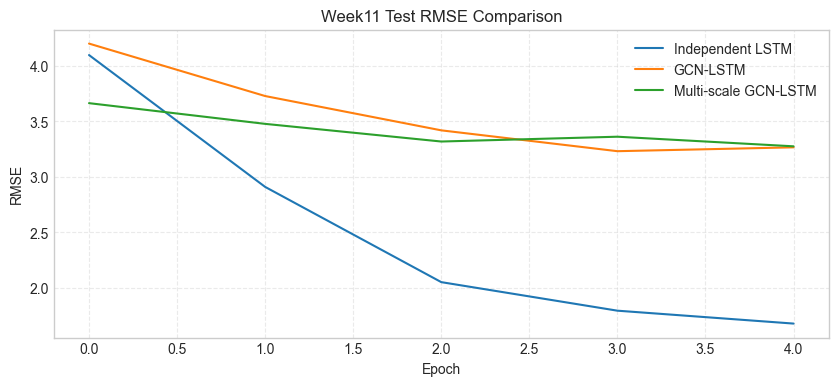

In [8]:
histories = {
    'Independent LSTM': baseline_history,
    'GCN-LSTM': gcn_lstm_history,
    'Multi-scale GCN-LSTM': multi_scale_history,
}

rows = []
for model_name, history in histories.items():
    rows.append({
        'model': model_name,
        'best_test_mae': min(history['test_mae']),
        'best_test_rmse': min(history['test_rmse']),
        'best_test_loss': min(history['test_loss']),
    })
results_df = pd.DataFrame(rows).sort_values('best_test_rmse')
display(results_df)

fig, ax = plt.subplots(figsize=(10, 4))
for model_name, history in histories.items():
    ax.plot(history['test_rmse'], label=model_name)
ax.set_title('Week11 Test RMSE Comparison')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSE')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.show()

## 7. 机制说明

`Independent LSTM` 只使用单站点历史，因此无法显式利用空间邻居。`GCN-LSTM` 先通过图卷积把邻居站点信息聚合到每个节点，再用 LSTM 捕捉时间依赖。如果 `GCN-LSTM` 或 `Multi-scale GCN-LSTM` 的误差低于独立 LSTM，就说明空间信息对多站点光伏预测有帮助。